# Hidden-State Cosine Similarity Across Depth

This version uses `PackedPretrainDataset` to stream real text, pack it into `PackedBatch` examples, and then unpack a few documents for analysis.
Each selected document is truncated to a shared analysis length so the hidden states can be compared directly across depth in a randomly initialized MoE model.
In addition to cross-document similarity, the notebook also tracks the average off-diagonal token-to-token cosine similarity inside each individual sequence.
For the MoE router, it also computes an expert-usage imbalance score based on the entropy of top-k expert assignments: `0` means perfectly balanced usage and `1` means maximally concentrated usage.

In [1]:
import itertools

import altair as alt
import datasets
import pandas as pd
import torch
import torch.nn.functional as F
from IPython.display import display
from transformers import AutoTokenizer

from nanomoe.data import PackedPretrainDataset, unpack_batch
from nanomoe.model import MoEConfig, create_model
from nanomoe.model.attention import Attention
from nanomoe.model.coord_check import _extract_tensor, _register_activation_hooks


def normalized_entropy(probs):
    probs = probs.clamp_min(torch.finfo(probs.dtype).eps)
    normalizer = torch.log(torch.tensor(float(probs.shape[-1]), dtype=probs.dtype, device=probs.device))
    return float((-(probs * probs.log()).sum() / normalizer).item())

/weka/scratch/enalisn1/xwang/nanomoe/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/weka/scratch/enalisn1/xwang/nanomoe/.venv/lib/python3.13/site-packages/transformers/utils/hub.py:110: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


In [34]:
# `Attention.forward` is torch-compiled in the repo. Fall back to eager mode in notebook
# environments that do not have a working CPU compiler.
if hasattr(Attention.forward, "__wrapped__"):
    Attention.forward = Attention.forward.__wrapped__

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.manual_seed(0)
if device.type == "cuda":
    torch.cuda.manual_seed_all(0)

# Lightweight defaults for notebook iteration. You can swap these for the repo's
# pretraining defaults if you want to inspect a different corpus.

tokenizer_name = "gpt2"
tokenizer = AutoTokenizer.from_pretrained(tokenizer_name)

num_layer = 64
constant = 1.0
alpha = 0.5
residual_scale = constant / (num_layer ** alpha)


config = MoEConfig(
    hidden_size=768,
    num_layers=num_layer,
    vocab_size=len(tokenizer),
    num_attention_heads=6,
    num_key_value_heads=3,
    intermediate_size=1024,
    num_experts=8,
    num_experts_per_tok=2,
    depth_alpha=None,
    residual_scale=residual_scale,
    tie_word_embeddings=True,
)

model = create_model(config).to(device).eval()
print(f"device={device}, tokenizer_vocab={len(tokenizer):,}, parameters={model.num_parameters():,}")

device=cuda, tokenizer_vocab=50,257, parameters=1,360,295,424


In [35]:
class HiddenStateCollector:
    def __init__(self):
        self.activations = {}

    def make_hook(self, probe, *, layer_index=None, layer_position=None):
        key = (probe, layer_index, layer_position)

        def _hook(_module, _inputs, output):
            tensor = _extract_tensor(output)
            if tensor is not None:
                self.activations[key] = tensor.detach().float().cpu()

        return _hook


def collect_hidden_states(model, input_ids):
    collector = HiddenStateCollector()
    handles = _register_activation_hooks(model, collector)
    try:
        with torch.no_grad():
            outputs = model(input_ids=input_ids, use_cache=False)
            collector.activations[("final_hidden", None, 1.0)] = outputs.hidden_states.detach().float().cpu()
    finally:
        for handle in handles:
            handle.remove()

    captured = []
    for (probe, layer_index, layer_position), tensor in collector.activations.items():
        if probe == "embed_tokens":
            depth = 0
            stage = "embed"
        elif probe == "block.out":
            depth = layer_index + 1
            stage = f"block_{depth}"
        elif probe == "norm":
            depth = model.config.num_layers + 1
            stage = "final_norm"
        elif probe == "router_logits":
            depth = layer_index + 1
            stage = f"router_{depth}"
        else:
            continue

        captured.append(
            {
                "probe": probe,
                "depth": depth,
                "stage": stage,
                "layer_index": layer_index,
                "layer_position": layer_position,
                "tensor": tensor,
            }
        )

    return sorted(captured, key=lambda row: row["depth"])

In [36]:
def load_analysis_sequences_from_packed_dataset(
    *,
    dataset_name,
    dataset_config,
    dataset_split,
    tokenizer,
    text_key,
    packed_seq_len,
    doc_max_seq_len,
    analysis_seq_len,
    num_sequences,
    max_examples,
    shuffle_buffer,
    max_packed_batches_to_scan,
    seed=0,
):
    hf_dataset = datasets.load_dataset(dataset_name, dataset_config, split=dataset_split, streaming=True)
    if max_examples is not None and hasattr(hf_dataset, "take"):
        hf_dataset = hf_dataset.take(max_examples)

    packed_dataset = PackedPretrainDataset(
        hf_dataset=hf_dataset,
        tokenizer=tokenizer,
        seq_len=packed_seq_len,
        text_key=text_key,
        prefetch_batches=2,
        seed=seed,
        add_special_tokens=False,
    )

    selected_tokens = []
    preview_rows = []
    packed_batches_seen = 0
    dataset_iter = iter(packed_dataset)

    try:
        while len(selected_tokens) < num_sequences and packed_batches_seen < max_packed_batches_to_scan:
            batch = next(dataset_iter)
            packed_batches_seen += 1
            for sequence in unpack_batch(batch):
                tokens = sequence["tokens"]
                if int(tokens.shape[0]) < analysis_seq_len:
                    continue

                trimmed = tokens[:analysis_seq_len].clone()
                selected_tokens.append(trimmed)
                preview_rows.append(
                    {
                        "sequence": f"doc_{len(selected_tokens) - 1}",
                        "source_length": int(tokens.shape[0]),
                        "used_length": int(trimmed.shape[0]),
                        "text_preview": tokenizer.decode(trimmed[:48].tolist(), skip_special_tokens=True),
                    }
                )
                if len(selected_tokens) >= num_sequences:
                    break
    finally:
        if hasattr(dataset_iter, "close"):
            dataset_iter.close()
        packed_dataset.stop()

    if len(selected_tokens) < num_sequences:
        raise ValueError(
            f"Only found {len(selected_tokens)} documents with at least {analysis_seq_len} tokens "
            f"after scanning {packed_batches_seen} packed batches"
        )

    return torch.stack(selected_tokens), pd.DataFrame(preview_rows), packed_batches_seen

In [37]:
dataset_name = "Salesforce/wikitext"
dataset_config = "wikitext-2-raw-v1"
dataset_split = "train"
text_key = "text"
max_examples = 512
shuffle_buffer = 64

packed_seq_len = 4096
num_sequences = 1
max_packed_batches_to_scan = 1000
analysis_seq_len = 256

input_ids, preview_df, packed_batches_seen = load_analysis_sequences_from_packed_dataset(
    dataset_name=dataset_name,
    dataset_config=dataset_config,
    dataset_split=dataset_split,
    tokenizer=tokenizer,
    text_key=text_key,
    packed_seq_len=packed_seq_len,
    doc_max_seq_len=None,
    analysis_seq_len=analysis_seq_len,
    num_sequences=num_sequences,
    max_examples=max_examples,
    shuffle_buffer=shuffle_buffer,
    max_packed_batches_to_scan=max_packed_batches_to_scan,
)

sequence_names = preview_df["sequence"].tolist()
input_ids = input_ids.to(device)

print(f"loaded {len(sequence_names)} documents after scanning {packed_batches_seen} packed batches")
preview_df

loaded 1 documents after scanning 1 packed batches


,sequence,source_length,used_length,text_preview
0,doc_0,293,256,"Following the break , the Blue Jackets were o..."


In [38]:
captured = collect_hidden_states(model, input_ids)

hidden_entries = [entry for entry in captured if entry["probe"] != "router_logits"]
router_entries = [entry for entry in captured if entry["probe"] == "router_logits"]

similarity_rows = []
drift_rows = []
within_sequence_rows = []
router_metric_rows = []
router_sequence_rows = []
router_load_rows = []
embed_flat = None

token_sims = []

for entry in hidden_entries:
    hidden = entry["tensor"]
    pooled = F.normalize(hidden.mean(dim=1), dim=-1)
    flattened = F.normalize(hidden.reshape(hidden.shape[0], -1), dim=-1)
    tokenwise = F.normalize(hidden, dim=-1)

    if entry["depth"] == 0:
        embed_flat = flattened.clone()

    for left_idx, right_idx in itertools.combinations(range(len(sequence_names)), 2):
        pair = f"{sequence_names[left_idx]} vs {sequence_names[right_idx]}"
        similarity_rows.extend(
            [
                {
                    "depth": entry["depth"],
                    "stage": entry["stage"],
                    "pair": pair,
                    "metric": "pooled_mean",
                    "value": float((pooled[left_idx] * pooled[right_idx]).sum()),
                },
                {
                    "depth": entry["depth"],
                    "stage": entry["stage"],
                    "pair": pair,
                    "metric": "flattened",
                    "value": float((flattened[left_idx] * flattened[right_idx]).sum()),
                },
                {
                    "depth": entry["depth"],
                    "stage": entry["stage"],
                    "pair": pair,
                    "metric": "tokenwise_mean",
                    "value": float((tokenwise[left_idx] * tokenwise[right_idx]).sum(dim=-1).mean()),
                },
            ]
        )

    for seq_idx, sequence_name in enumerate(sequence_names):
        token_cos = tokenwise[seq_idx] @ tokenwise[seq_idx].T
        off_diag_mask = ~torch.eye(token_cos.shape[0], dtype=torch.bool)
        within_sequence_rows.append(
            {
                "depth": entry["depth"],
                "stage": entry["stage"],
                "sequence": sequence_name,
                "avg_token_cosine": float(token_cos[off_diag_mask].mean()),
            }
        )
    token_sims.append(float(token_cos[off_diag_mask].mean()))
    for seq_idx, sequence_name in enumerate(sequence_names):
        drift_rows.append(
            {
                "depth": entry["depth"],
                "stage": entry["stage"],
                "sequence": sequence_name,
                "cosine_to_embed": float((flattened[seq_idx] * embed_flat[seq_idx]).sum()),
            }
        )

router_metrics_rows = []

for entry in router_entries:
    router_logits = entry["tensor"].reshape(len(sequence_names), analysis_seq_len, config.num_experts)
    router_module = model.layers[entry["layer_index"]].mlp.router
    router_probs = router_module.normalize_router_logits(router_logits.reshape(-1, config.num_experts)).reshape(
        len(sequence_names), analysis_seq_len, config.num_experts
    )
    topk_indices = torch.topk(router_probs, config.num_experts_per_tok, dim=-1).indices
    assignments = F.one_hot(topk_indices, num_classes=config.num_experts).to(router_probs.dtype)

    expert_load = assignments.sum(dim=(0, 1, 2)) / (len(sequence_names) * analysis_seq_len * config.num_experts_per_tok)
    expert_importance = router_probs.mean(dim=(0, 1))
    usage_entropy = normalized_entropy(expert_load)
    importance_entropy = normalized_entropy(expert_importance)

    router_metric_rows.append(
        assignments
    )
    # for expert_idx in range(config.num_experts):
    #     router_load_rows.append(
    #         {
    #             "depth": entry["depth"],
    #             "stage": entry["stage"],
    #             "expert": f"expert_{expert_idx}",
    #             "load": float(expert_load[expert_idx]),
    #             "importance": float(expert_importance[expert_idx]),
    #         }
    #     )

    # per_sequence_load = assignments.sum(dim=(1, 2)) / (analysis_seq_len * config.num_experts_per_tok)
    # for seq_idx, sequence_name in enumerate(sequence_names):
    #     router_sequence_rows.append(
    #         {
    #             "depth": entry["depth"],
    #             "stage": entry["stage"],
    #             "sequence": sequence_name,
    #             "usage_imbalance": 1.0 - normalized_entropy(per_sequence_load[seq_idx]),
    #         }
    #     )

similarity_df = pd.DataFrame(similarity_rows)
drift_df = pd.DataFrame(drift_rows)
within_sequence_df = pd.DataFrame(within_sequence_rows)


display(similarity_df.head())
display(drift_df.head())
display(within_sequence_df.head())

""


,depth,stage,sequence,cosine_to_embed
0,0,embed,doc_0,1.000004
1,1,block_1,doc_0,0.840370
2,2,block_2,doc_0,0.666586
3,3,block_3,doc_0,0.505096
4,4,block_4,doc_0,0.395157


,depth,stage,sequence,avg_token_cosine
0,0,embed,doc_0,0.015791
1,1,block_1,doc_0,0.091165
2,2,block_2,doc_0,0.272626
3,3,block_3,doc_0,0.503533
4,4,block_4,doc_0,0.652026


In [39]:
all_loads = []
for entry in router_entries:
    router_logits = entry["tensor"].reshape(len(sequence_names), analysis_seq_len, config.num_experts)
    router_module = model.layers[entry["layer_index"]].mlp.router
    router_probs = router_module.normalize_router_logits(router_logits.reshape(-1, config.num_experts)).reshape(
        len(sequence_names), analysis_seq_len, config.num_experts
    )
    topk_indices = torch.topk(router_probs, config.num_experts_per_tok, dim=-1).indices
    assignments = F.one_hot(topk_indices, num_classes=config.num_experts).to(router_probs.dtype).sum([2])

    expert_load = assignments.sum(dim=(0, 1)) / (len(sequence_names) * analysis_seq_len * config.num_experts_per_tok)
    all_loads.append(expert_load)
    # expert_importance = router_probs.mean(dim=(0, 1))
    # usage_entropy = normalized_entropy(expert_load)
    # importance_entropy = normalized_entropy(expert_importance)

In [40]:
token_sims

[0.01579095609486103,
 0.09116490930318832,
 0.27262574434280396,
 0.5035325884819031,
 0.6520255208015442,
 0.7420680522918701,
 0.7748003602027893,
 0.8064540028572083,
 0.8298565149307251,
 0.8417568802833557,
 0.8532599806785583,
 0.858610987663269,
 0.8633865118026733,
 0.8659119606018066,
 0.8691960573196411,
 0.8712618947029114,
 0.8745435476303101,
 0.8789357542991638,
 0.8829363584518433,
 0.8849802017211914,
 0.8837084174156189,
 0.8891564607620239,
 0.8906897306442261,
 0.8927088975906372,
 0.8917070031166077,
 0.8943086266517639,
 0.8954913020133972,
 0.8986652493476868,
 0.8999236226081848,
 0.9022818803787231,
 0.9038686752319336,
 0.9028472304344177,
 0.9025871753692627,
 0.9022114872932434,
 0.9036446213722229,
 0.9049238562583923,
 0.9061275720596313,
 0.9076788425445557,
 0.9090664386749268,
 0.9087098240852356,
 0.9098241329193115,
 0.9088178873062134,
 0.908098042011261,
 0.9091286659240723,
 0.9094316363334656,
 0.9098016619682312,
 0.9111777544021606,
 0.912211239

In [33]:
token_sims

[0.01579095609486103,
 0.4715062081813812,
 0.7910665273666382,
 0.8490610122680664,
 0.8708924055099487,
 0.8824596405029297,
 0.8871940970420837,
 0.8925803899765015,
 0.8985123634338379,
 0.9014585018157959,
 0.905299186706543,
 0.906190812587738,
 0.9075251817703247,
 0.9072583913803101,
 0.9078048467636108,
 0.9100252985954285,
 0.9107272028923035,
 0.9136531949043274,
 0.9178222417831421,
 0.9191243052482605,
 0.9182333946228027,
 0.9208678007125854,
 0.9212734699249268,
 0.9221333861351013,
 0.9213715195655823,
 0.9208535552024841,
 0.9207571148872375,
 0.9235802888870239,
 0.9245027303695679,
 0.9253196716308594,
 0.9250569343566895,
 0.9241300225257874,
 0.9230189919471741,
 0.9214388728141785,
 0.9220718741416931,
 0.9240575432777405,
 0.924876868724823,
 0.925706684589386,
 0.9259881377220154,
 0.9256088137626648,
 0.9262314438819885,
 0.9268628358840942,
 0.9264682531356812,
 0.9266553521156311,
 0.9276740550994873,
 0.9279798269271851,
 0.9287382364273071,
 0.9284669160842

Text(0.5, 1.02, 'Router Load and Token Similarity Across Layers\n(depth_alpha=None)')

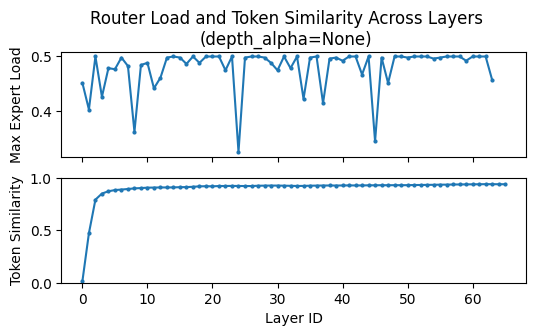

In [32]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(6, 3), sharex=True)
ax[0].plot(np.stack(all_loads).max(-1), marker='o', markersize=2)
ax[1].plot(token_sims, marker='o', markersize=2)
ax[1].set_xlabel("Layer ID")
ax[0].set_ylabel("Max Expert Load")
ax[1].set_ylabel("Token Similarity")
# ax[0].set_ylim(0, 0.26)
ax[1].set_ylim(0.0, 1.0)
fig.suptitle("Router Load and Token Similarity Across Layers\n(depth_alpha={})".format(config.depth_alpha), y=1.02)

Text(0.5, 1.02, 'Router Load and Token Similarity Across Layers\n(depth_alpha=None)')

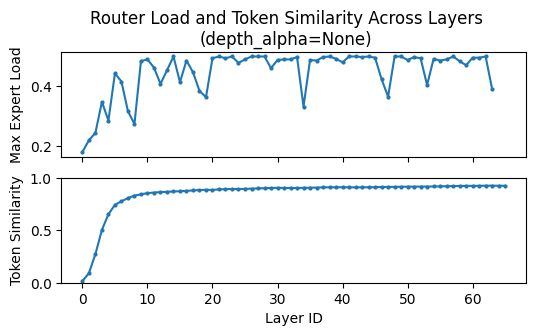

In [41]:
import numpy as np
import matplotlib.pyplot as plt
fig, ax = plt.subplots(2, 1, figsize=(6, 3), sharex=True)
ax[0].plot(np.stack(all_loads).max(-1), marker='o', markersize=2)
ax[1].plot(token_sims, marker='o', markersize=2)
ax[1].set_xlabel("Layer ID")
ax[0].set_ylabel("Max Expert Load")
ax[1].set_ylabel("Token Similarity")
# ax[0].set_ylim(0, 0.26)
ax[1].set_ylim(0.0, 1.0)
fig.suptitle("Router Load and Token Similarity Across Layers\n(depth_alpha={})".format(config.depth_alpha), y=1.02)